In [1]:
import sys, os
sys.path.insert(0, '.')
sys.path.insert(0, os.path.join('..', 'step2_meta_qlearn'))

import numpy as np
import matplotlib.pyplot as plt
from comparison import run_comparison, print_results

seeds = [42, 123, 456]
results = {seed: run_comparison(seed=seed) for seed in seeds}

In [2]:
for seed in seeds:
    print(f"--- Seed {seed} ---")
    print_results(results[seed])
    print()

--- Seed 42 ---
LP principal utility:      0.48
Linear principal utility:  0.47
Gap ratio:                 1.01
Theoretical bound (n=2):   2.00

--- Seed 123 ---
LP principal utility:      0.47
Linear principal utility:  0.46
Gap ratio:                 1.01
Theoretical bound (n=2):   2.00

--- Seed 456 ---
LP principal utility:      0.53
Linear principal utility:  0.53
Gap ratio:                 1.01
Theoretical bound (n=2):   2.00



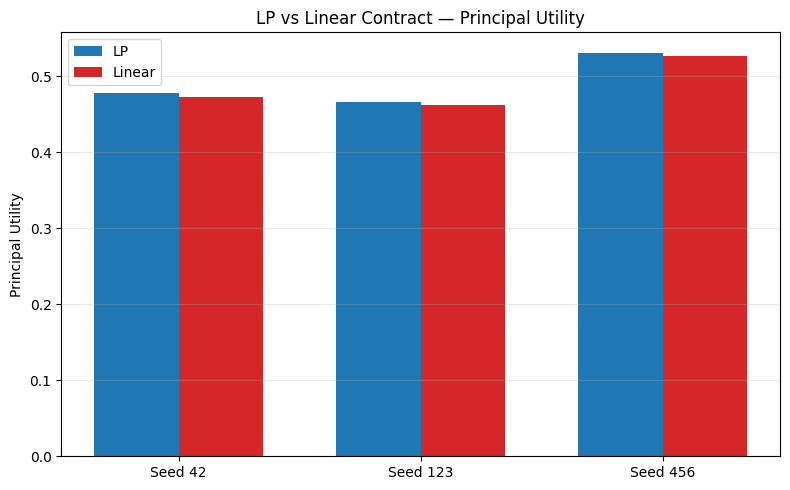

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

x     = np.arange(len(seeds))
width = 0.35

ax.bar(x - width / 2,
       [results[s]['lp_final'] for s in seeds],
       width, label='LP', color='#1f77b4')

ax.bar(x + width / 2,
       [results[s]['linear_final'] for s in seeds],
       width, label='Linear', color='#d62728')

ax.set_xticks(x)
ax.set_xticklabels([f'Seed {s}' for s in seeds])
ax.set_ylabel('Principal Utility')
ax.set_title('LP vs Linear Contract — Principal Utility')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

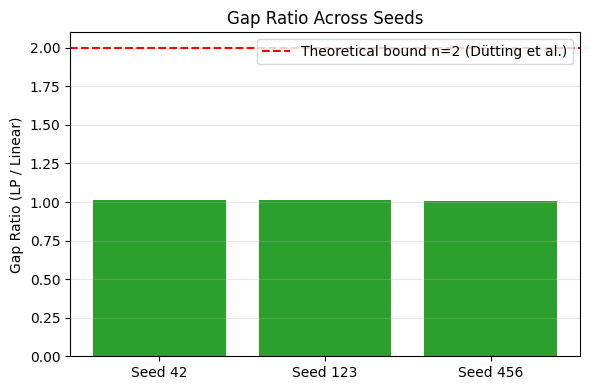

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

gap_ratios = [results[s]['gap_ratio'] for s in seeds]

ax.bar([f'Seed {s}' for s in seeds], gap_ratios, color='#2ca02c')
ax.axhline(2.0, color='red', linestyle='--',
           label='Theoretical bound n=2 (Dütting et al.)')

ax.set_ylabel('Gap Ratio (LP / Linear)')
ax.set_title('Gap Ratio Across Seeds')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()